In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
data = pd.read_csv('../dataset/Mall_Customers.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

data.head()

Dataset loaded successfully!
Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Dataset Information:")
data.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [4]:
print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
numeric_columns = data.select_dtypes(include=[np.number]).columns

data[numeric_columns] = data[numeric_columns].fillna(
    data[numeric_columns].mean()
)

print("Missing values handled successfully!")
print(data.isnull().sum())

Missing values handled successfully!
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = data[features]

print("Selected features:")
print(features)

X.head()

Selected features:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features standardized successfully!")
print(X_scaled[:5])

Features standardized successfully!
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


In [8]:
sse = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    sse.append(kmeans.inertia_)

print("SSE values:")
print(sse)

SSE values:
[600.0, 389.3861889564371, 295.2122461555488, 205.22514747675916, 168.24758017556837, 133.86842085478855, 117.01155455889813, 103.87329152383714, 93.09289110041726, 82.385153645266]


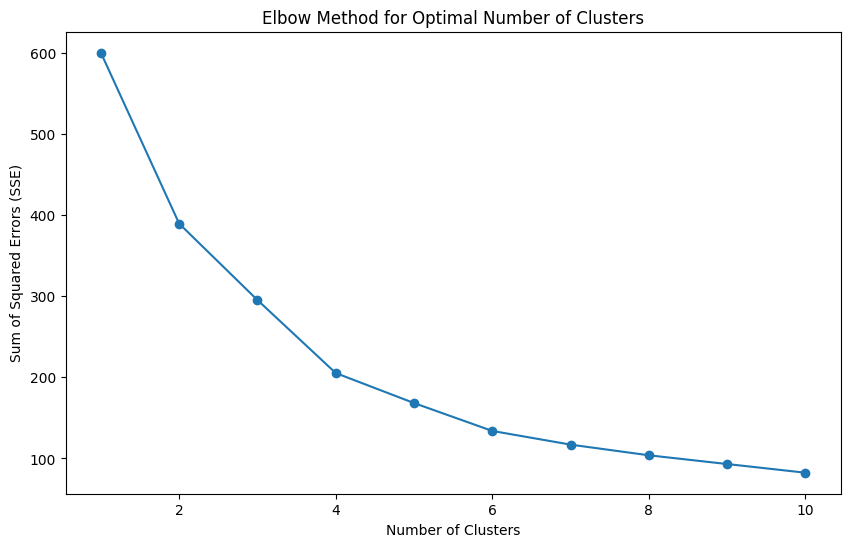

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    sse,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal Number of Clusters')

plt.savefig(
    '../outputs/elbow_method.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [10]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        cluster_labels
    )
    
    silhouette_scores.append(score)

print("Silhouette Scores:")

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: {score:.4f}")

Silhouette Scores:
K = 2: 0.3355
K = 3: 0.3578
K = 4: 0.4040
K = 5: 0.4166
K = 6: 0.4284
K = 7: 0.4172
K = 8: 0.4082
K = 9: 0.4177
K = 10: 0.4066


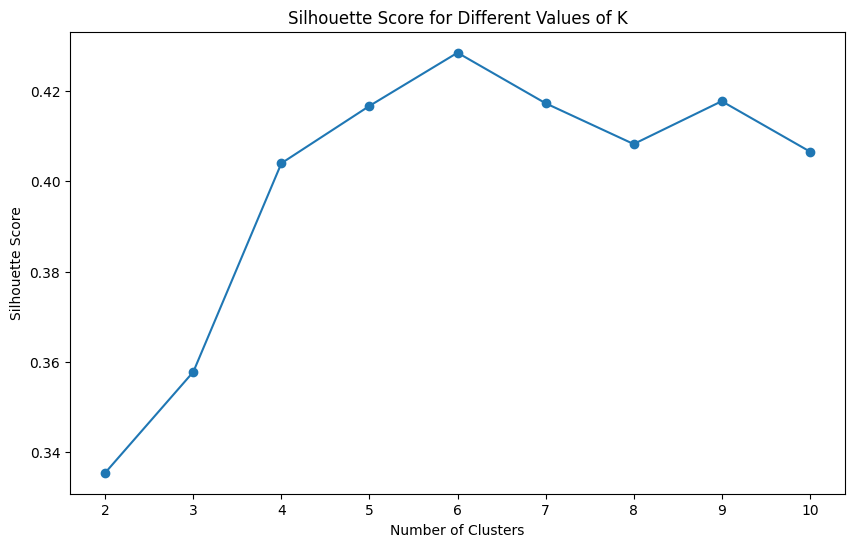

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Values of K')

plt.savefig(
    '../outputs/silhouette_scores.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [12]:
optimal_k = 5

print("Optimal number of clusters:", optimal_k)

Optimal number of clusters: 5


In [13]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

data['Cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed successfully!")

data.head()

K-Means clustering completed successfully!


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [14]:
cluster_counts = data['Cluster'].value_counts().sort_index()

print("Number of customers in each cluster:")
print(cluster_counts)

Number of customers in each cluster:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


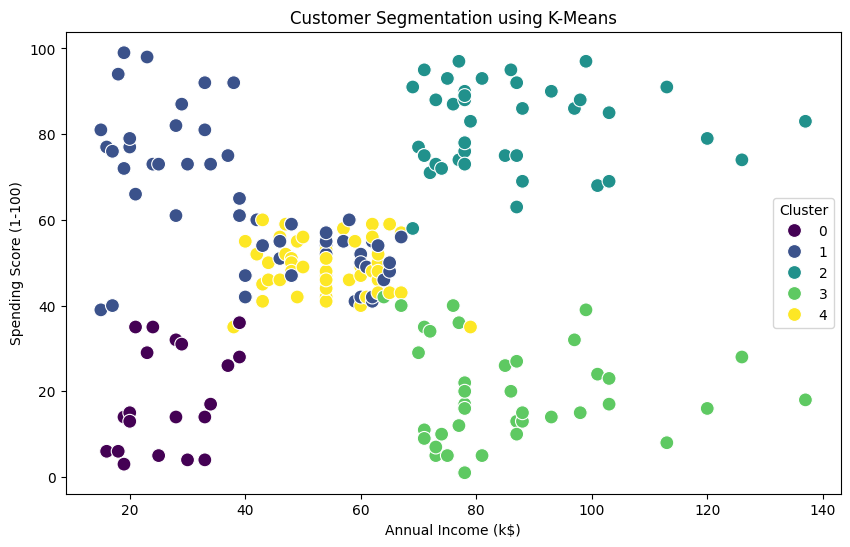

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.savefig(
    '../outputs/customer_clusters.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [16]:
cluster_centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=features
)

cluster_centers_df['Cluster'] = range(optimal_k)

print("Cluster Centers:")
cluster_centers_df

Cluster Centers:


,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,46.250000,26.750000,18.350000,0
1,25.185185,41.092593,62.240741,1
2,32.875000,86.100000,81.525000,2
3,39.871795,86.102564,19.358974,3
4,55.638298,54.382979,48.851064,4


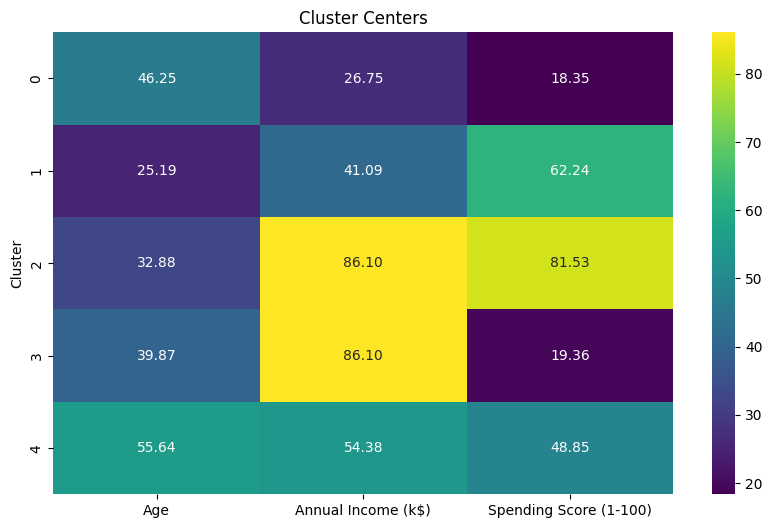

In [17]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_centers_df.set_index('Cluster'),
    annot=True,
    fmt='.2f',
    cmap='viridis'
)

plt.title('Cluster Centers')

plt.savefig(
    '../outputs/cluster_visualization.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

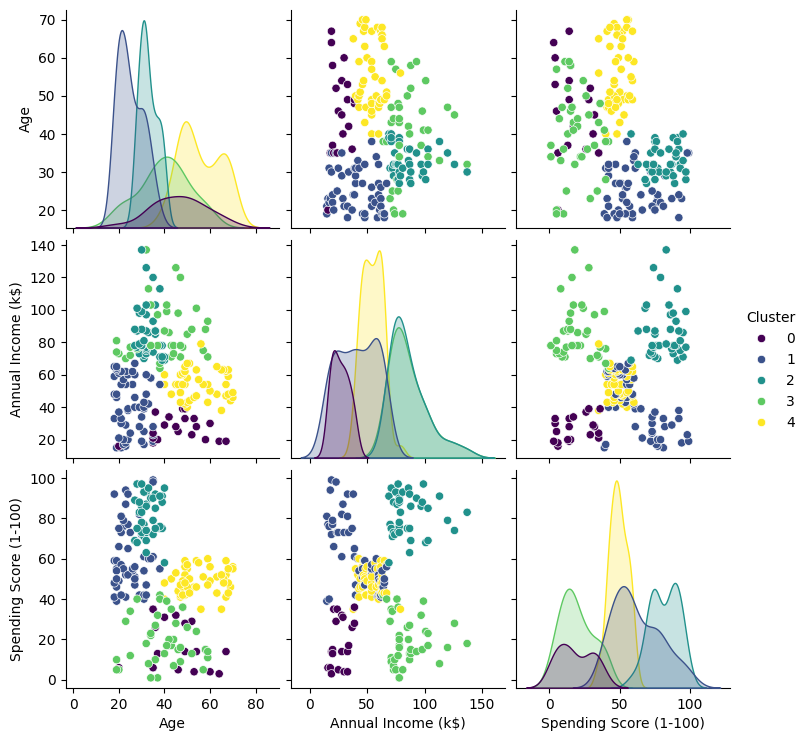

In [18]:
sns.pairplot(
    data,
    hue='Cluster',
    vars=features,
    palette='viridis'
)

plt.savefig(
    '../outputs/pairplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

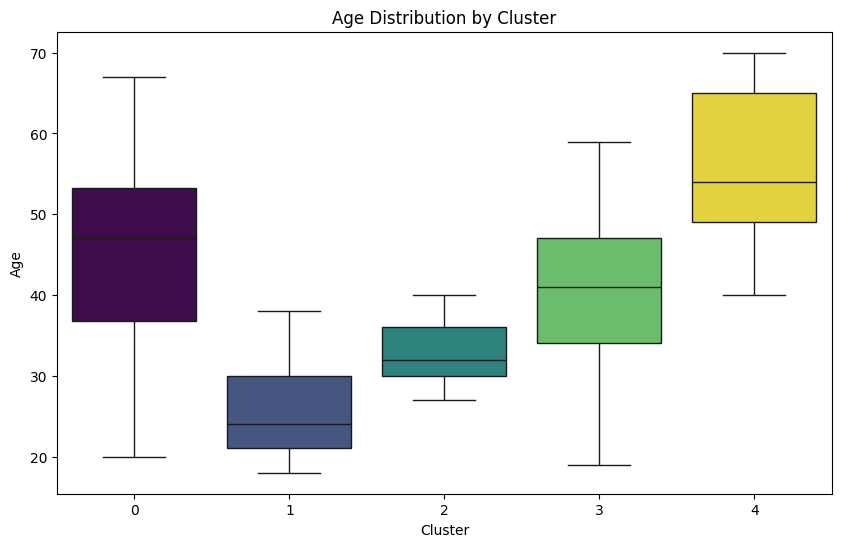

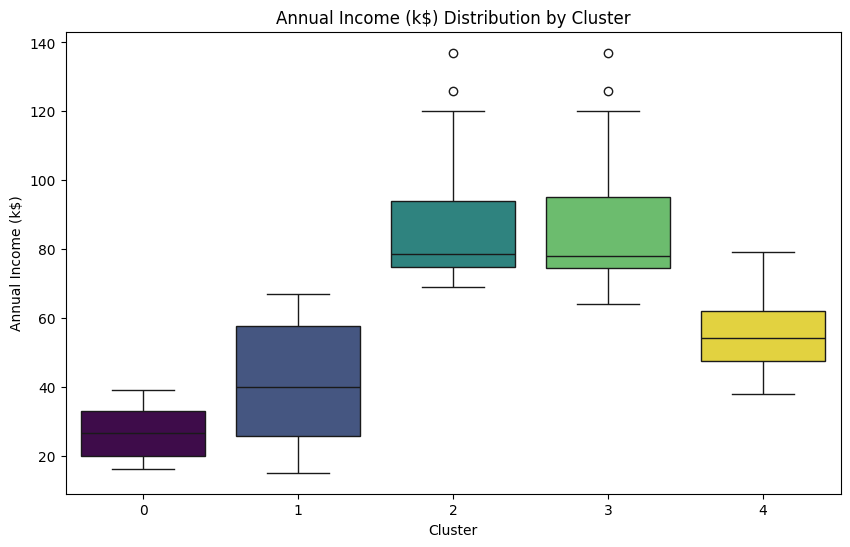

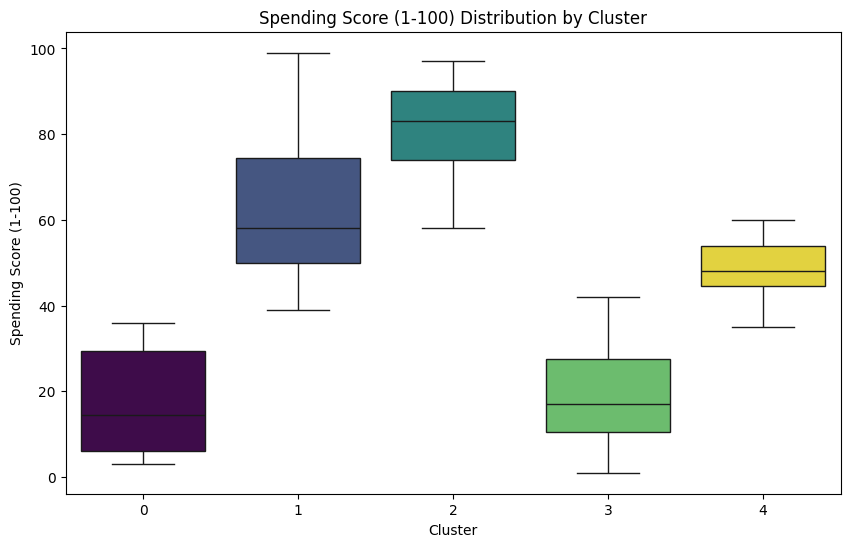

In [19]:
for feature in features:
    
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(
        data=data,
        x='Cluster',
        y=feature,
        hue='Cluster',
        palette='viridis',
        legend=False
    )
    
    plt.title(f'{feature} Distribution by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    
    filename = (
        feature
        .replace(' ', '_')
        .replace('(', '')
        .replace(')', '')
        .replace('/', '_')
    )
    
    plt.savefig(
        f'../outputs/{filename}_boxplot.png',
        dpi=300,
        bbox_inches='tight'
    )
    
    plt.show()

In [20]:
cluster_summary = (
    data.groupby('Cluster')[features]
    .mean()
    .reset_index()
)

print("Customer Cluster Summary:")
cluster_summary

Customer Cluster Summary:


,Cluster,Age,Annual Income (k$),Spending Score (1-100)
0,0,46.250000,26.750000,18.350000
1,1,25.185185,41.092593,62.240741
2,2,32.875000,86.100000,81.525000
3,3,39.871795,86.102564,19.358974
4,4,55.638298,54.382979,48.851064


In [21]:
output_file = '../outputs/clustered_customers.csv'

data.to_csv(
    output_file,
    index=False
)

print("Clustered customer data saved successfully!")
print("File:", output_file)

Clustered customer data saved successfully!
File: ../outputs/clustered_customers.csv
